In [2]:
pip install neuralforecast

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | enc_embedding | DataEmbedding | 512    | train
4 | dec_embedding | DataEmbedding | 512    | train
5 | encoder       | TransEncoder  | 199 K  | train
6 | decoder       | TransDecoder  | 141 K  | train
--------------------------------------------------------
342 K     Trainable params
0         Non-trainable params
342 K     Total params
1.369     Total estimated model params size (MB)
77        Modules in train mode
0         Modules in eval mode


Entrenando el modelo Informer...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Columnas disponibles: ['epoch', 'ptl/val_loss', 'step', 'train_loss_epoch', 'train_loss_step', 'valid_loss']


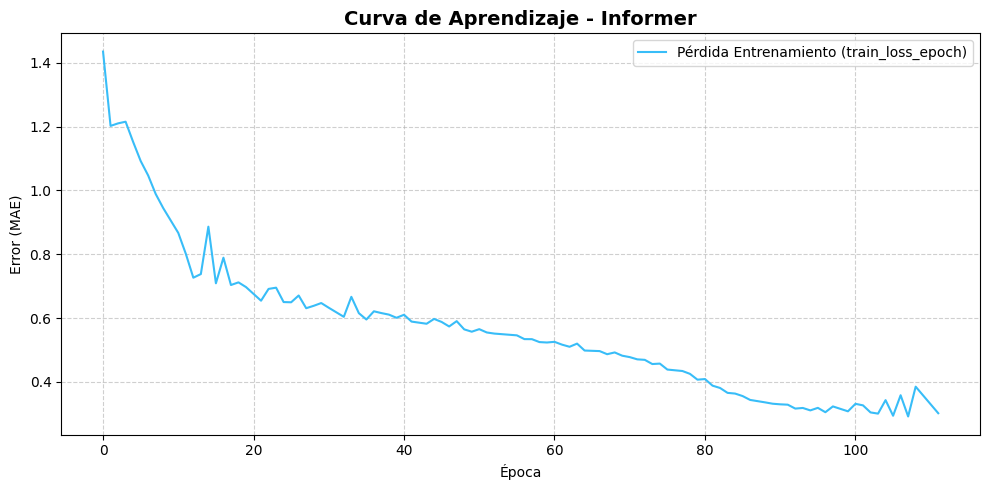

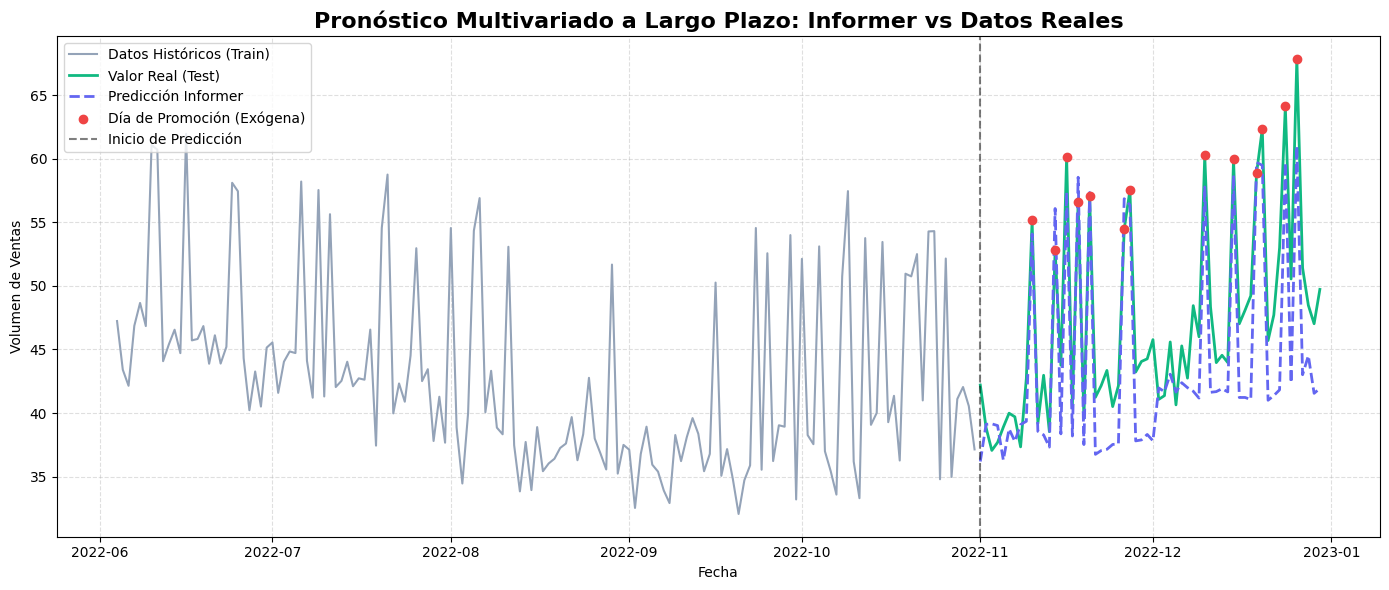

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import Informer
from pytorch_lightning.loggers import CSVLogger
import os

# ==========================================
# 1. GENERACIÓN DE DATOS SINTÉTICOS COMPLEJOS
# ==========================================
np.random.seed(42)
fechas = pd.date_range(start='2020-01-01', periods=1095, freq='D')
tendencia = np.linspace(10, 50, 1095)
estacionalidad = 10 * np.sin(2 * np.pi * fechas.dayofyear / 365.25)
promocion = np.random.choice([0, 1], size=1095, p=[0.8, 0.2])
ruido = np.random.normal(0, 2, 1095)

y = tendencia + estacionalidad + (15 * promocion) + ruido

df = pd.DataFrame({
    'unique_id': 'Ventas_Retail',
    'ds': fechas,
    'y': y,
    'promocion': promocion
})

horizonte = 60
df_train = df.iloc[:-horizonte]
df_test = df.iloc[-horizonte:]

# ==========================================
# 2. CONFIGURACIÓN DEL MODELO INFORMER
# ==========================================
logger = CSVLogger("logs", name="Informer_logs")

model = Informer(
    h=horizonte,  #Cuantos dias al futuro
    input_size=120, #Cuantos dias del historico utiliza para la prediccion
    hidden_size=128, #Libreta pequeña (ej: 32) → anota poco, puede olvidar patrones importantes, Libreta grande (ej: 512) → anota mucho detalle, pero tarda más en procesar
    futr_exog_list=['promocion'], #Variables externas conocidas en el futuro: le dice al modelo que tendrá disponible el calendario de promociones al predecir
    scaler_type='standard', #escala los datos a media=0 y desviación=1 antes de entrenar, mejora la estabilidad
    learning_rate=1e-3, #Velocidad de aprendizaje: qué tan grandes son los ajustes en cada paso del entrenamiento (0.001)
    max_steps=100, #Es cuántas veces el modelo repasa los datos para aprender.
    val_check_steps=10, #Cada cuántos pasos evalúa el modelo contra los datos de validación
    early_stop_patience_steps=5, #Parada temprana: si después de 4 evaluaciones sin mejorar, detiene el entrenamiento para evitar sobreajuste
    logger=logger #Es simplemente la bitácora del entrenamiento. Como un diario donde el modelo anota en cada paso:
)

nf = NeuralForecast(models=[model], freq='D')

# ==========================================
# 3. ENTRENAMIENTO Y PREDICCIÓN
# ==========================================
print("Entrenando el modelo Informer...")
nf.fit(df=df_train, val_size=horizonte)

df_future = df_test[['unique_id', 'ds', 'promocion']]

#Prepara lo único que el modelo puede saber del futuro: las fechas y si habrá promoción o no esos días.
#Nótese que no incluye y (las ventas reales), porque eso es precisamente lo que queremos predecir.

predicciones = nf.predict(futr_df=df_future)

#El modelo usa lo que aprendió en .fit() y genera los 60 valores de ventas predichos, guardándolos en el dataframe predicciones.

# ==========================================
# 4. GRÁFICA 1: CURVA DE APRENDIZAJE (LOSS)
# ==========================================
import glob

log_dirs = sorted(glob.glob("logs/Informer_logs/version_*/metrics.csv"))
log_dir = log_dirs[-1] if log_dirs else None

if log_dir and os.path.exists(log_dir):
    metrics = pd.read_csv(log_dir)
    print("Columnas disponibles:", metrics.columns.tolist())

    train_loss = metrics['train_loss_epoch'].dropna()

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss.index, train_loss.values,
             label='Pérdida Entrenamiento (train_loss_epoch)', color='#38bdf8')
    plt.title('Curva de Aprendizaje - Informer', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Error (MAE)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. GRÁFICA 2: RESULTADO VS REAL (FORECAST)
# ==========================================
resultado = df_test.merge(predicciones, on=['unique_id', 'ds'], how='left')

plt.figure(figsize=(14, 6))
plt.plot(df_train['ds'].tail(150), df_train['y'].tail(150), label='Datos Históricos (Train)', color='#94a3b8')
plt.plot(resultado['ds'], resultado['y'], label='Valor Real (Test)', color='#10b981', linewidth=2)

# 3. GRAFICAMOS LA PREDICCIÓN DEL INFORMER
plt.plot(resultado['ds'], resultado['Informer'], label='Predicción Informer', color='#6366f1', linewidth=2, linestyle='--')

dias_promo = resultado[resultado['promocion'] == 1]
plt.scatter(dias_promo['ds'], dias_promo['y'], color='#ef4444', label='Día de Promoción (Exógena)', zorder=5)

plt.axvline(x=resultado['ds'].iloc[0], color='black', linestyle='--', alpha=0.5, label='Inicio de Predicción')

plt.title('Pronóstico Multivariado a Largo Plazo: Informer vs Datos Reales', fontsize=16, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Volumen de Ventas')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()